<a href="https://colab.research.google.com/github/tharun2128/DEEP-LEARNING/blob/main/ex2taskC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully!
Training data: (50000, 28, 28)
Validation data: (10000, 28, 28)

Training: SGD
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6060 - loss: 1.4848 - val_accuracy: 0.8377 - val_loss: 0.7481
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8495 - loss: 0.5981 - val_accuracy: 0.8880 - val_loss: 0.4434
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8822 - loss: 0.4364 - val_accuracy: 0.9039 - val_loss: 0.3638
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8945 - loss: 0.3774 - val_accuracy: 0.9092 - val_loss: 0.3303
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9021 - loss: 0.3450 - val_accuracy: 0.9156 - val_loss: 0.3055
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9089 - loss: 0.3226 - val_accuracy: 0.9180 - val_loss: 0.2894
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9132 - 

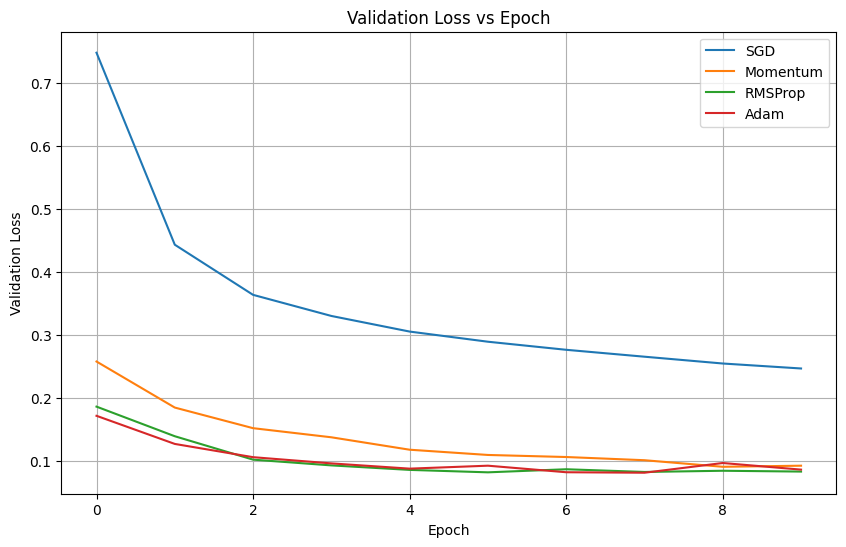

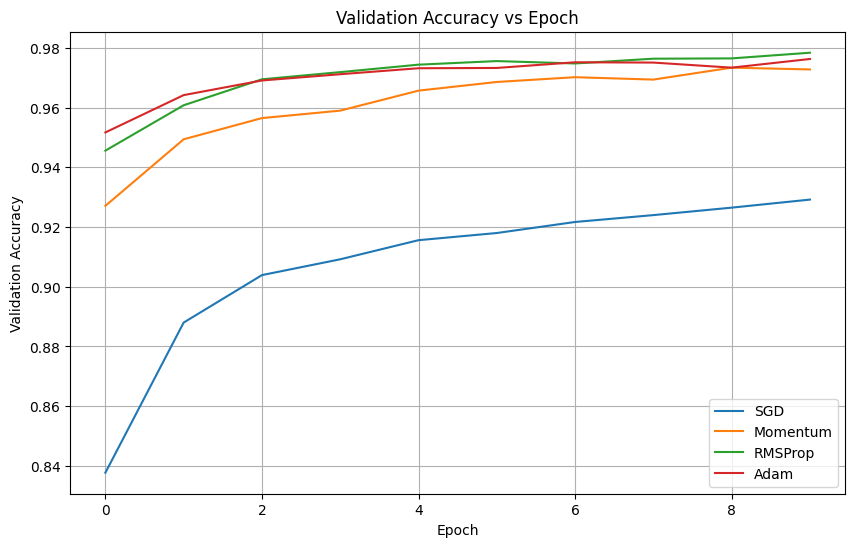

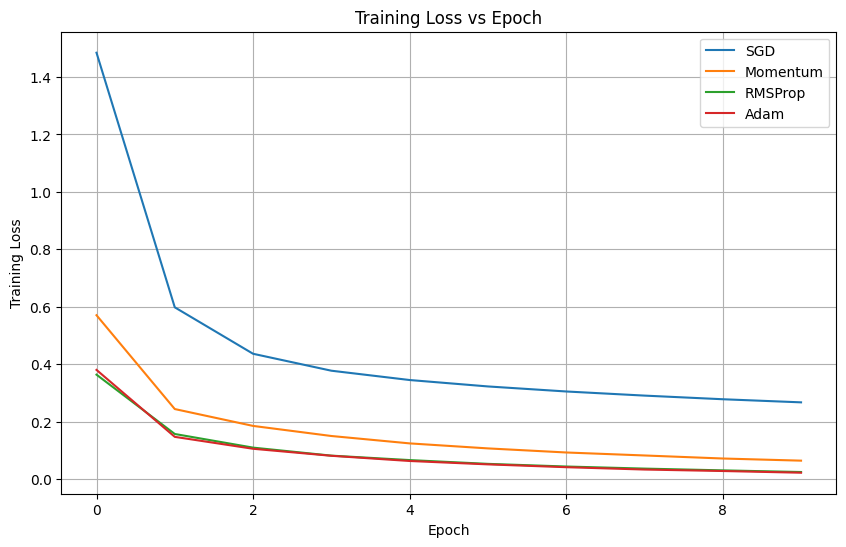

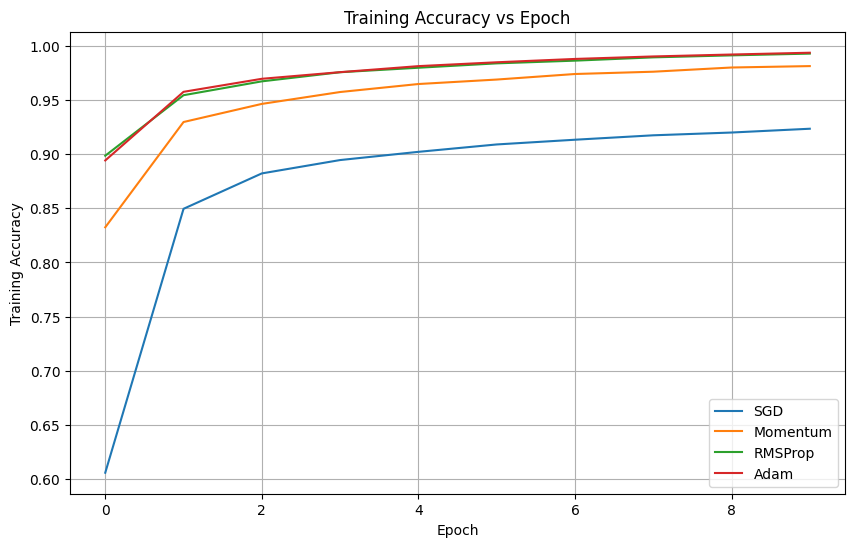



FINAL OPTIMIZER COMPARISON

Optimizer: SGD
Training Loss       : 0.2672
Validation Loss     : 0.2469
Training Accuracy   : 0.9234
Validation Accuracy : 0.9292

Optimizer: Momentum
Training Loss       : 0.0642
Validation Loss     : 0.0926
Training Accuracy   : 0.9812
Validation Accuracy : 0.9728

Optimizer: RMSProp
Training Loss       : 0.0246
Validation Loss     : 0.0833
Training Accuracy   : 0.9927
Validation Accuracy : 0.9784

Optimizer: Adam
Training Loss       : 0.0221
Validation Loss     : 0.0864
Training Accuracy   : 0.9935
Validation Accuracy : 0.9763


In [2]:
# ============================================================
# EXPERIMENT 2 - TASK C
# COMPARISON OF OPTIMIZATION ALGORITHMS
#
# Name: THARUN
# Roll No: 24BAD126
# ============================================================

import tensorflow as tf
import matplotlib.pyplot as plt

# -------------------- LOAD DATASET --------------------

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Validation data
x_val = x_train[-10000:]
y_val = y_train[-10000:]

x_train = x_train[:-10000]
y_train = y_train[:-10000]

print("Dataset loaded successfully!")
print("Training data:", x_train.shape)
print("Validation data:", x_val.shape)


# -------------------- CREATE ANN MODEL --------------------

def create_model(optimizer):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(128, activation="relu"),

        tf.keras.layers.Dense(64, activation="relu"),

        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# -------------------- DEFINE OPTIMIZERS --------------------

optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),

    "Momentum": tf.keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),

    "RMSProp": tf.keras.optimizers.RMSprop(
        learning_rate=0.001
    ),

    "Adam": tf.keras.optimizers.Adam(
        learning_rate=0.001
    )
}


# -------------------- TRAIN MODELS --------------------

histories = {}

for name, optimizer in optimizers.items():

    print("\n" + "=" * 50)
    print("Training:", name)
    print("=" * 50)

    model = create_model(optimizer)

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=10,
        batch_size=128,
        verbose=1
    )

    histories[name] = history


# -------------------- VALIDATION LOSS GRAPH --------------------

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["val_loss"],
        label=name
    )

plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid()
plt.show()


# -------------------- VALIDATION ACCURACY GRAPH --------------------

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=name
    )

plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid()
plt.show()


# -------------------- TRAINING LOSS GRAPH --------------------

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["loss"],
        label=name
    )

plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid()
plt.show()


# -------------------- TRAINING ACCURACY GRAPH --------------------

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["accuracy"],
        label=name
    )

plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.legend()
plt.grid()
plt.show()


# -------------------- FINAL RESULTS --------------------

print("\n")
print("=" * 75)
print("FINAL OPTIMIZER COMPARISON")
print("=" * 75)

for name, history in histories.items():

    print("\nOptimizer:", name)

    print(
        "Training Loss       :",
        round(history.history["loss"][-1], 4)
    )

    print(
        "Validation Loss     :",
        round(history.history["val_loss"][-1], 4)
    )

    print(
        "Training Accuracy   :",
        round(history.history["accuracy"][-1], 4)
    )

    print(
        "Validation Accuracy :",
        round(history.history["val_accuracy"][-1], 4)
    )